# Time-Series Periodicity & Seasonality Analysis (EDA Part 3)
## Hourly Pharmaceutical Sales Forecasting Dataset

---

### Executive Summary & Notebook Overview
This notebook executes a dedicated **Periodicity, Seasonality, and Calendar Pattern Analysis** for the hourly pharmaceutical sales dataset (`dataset/saleshourly.csv`). The analysis evaluates temporal demand patterns across multiple time scales:
- **Hourly Intraday Cycles** (0-23h opening/peak/night hours)
- **Day-of-Week Patterns** (Weekday vs Weekend purchasing shifts)
- **Weekday x Hour Operational Interactions** (Demand hotspots)
- **Overall Monthly Seasonality** (Jan-Dec allergy/flu cycles)
- **Monthly Seasonality in Every Year** (Multi-year seasonal shape invariance and Year x Month heatmaps)
- **Weekly Seasonality across Every Week, Month, and Year** (Week 1-52 trajectories, Month x Weekday heatmaps, Year x Weekday stability)
- **Multi-Year Annual Growth Trajectories** (YoY trend shifts across 2014–2019)

---

### Table of Contents
1. [18. Hourly Pattern Analysis](#18.-Hourly-Pattern-Analysis)
2. [19. Weekday Analysis](#19.-Weekday-Analysis)
3. [20. Weekday x Hour Analysis](#20.-Weekday-x-Hour-Analysis)
4. [21. Monthly Seasonality Analysis](#21.-Monthly-Seasonality-Analysis)
5. [22. Monthly Seasonality in Every Year](#22.-Monthly-Seasonality-in-Every-Year)
6. [23. Weekly Seasonality in Every Week, Month, and Year](#23.-Weekly-Seasonality-in-Every-Week,-Month,-and-Year)
7. [24. Yearly Analysis](#24.-Yearly-Analysis)
8. [25. Summary of Findings & Key Takeaways](#25.-Summary-of-Findings-&-Key-Takeaways)

---


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:", sns.__version__)


Pandas version: 3.0.5
Numpy version: 1.26.4
Matplotlib version: 3.10.5
Seaborn version: 0.13.2


In [15]:
DATA_PATH = '../dataset/saleshourly_preprocessed.csv'
df_raw = pd.read_csv(DATA_PATH)

df_season = df_raw.copy()
df_season['datum_dt'] = pd.to_datetime(df_season['datum'], format='%m/%d/%Y %H:%M')
df_season = df_season.sort_values('datum_dt').set_index('datum_dt')

drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Feature Encodings for Multi-Scale Analysis
df_season['Year'] = df_season.index.year
df_season['Month'] = df_season.index.month
df_season['Week'] = df_season.index.isocalendar().week.astype(int)
df_season['Weekday Name'] = df_season.index.day_name()
df_season['Hour'] = df_season.index.hour
df_season['Total_Sales'] = df_season[drug_cols].sum(axis=1)

print(f"Dataset Range: {df_season.index.min()} to {df_season.index.max()}")
print(f"Total Hourly Records: {len(df_season):,}")


Dataset Range: 2014-01-02 08:00:00 to 2019-10-08 19:00:00
Total Hourly Records: 50,532


## 18. Hourly Pattern Analysis

Analyze hourly intraday demand distributions (0 to 23) to identify pharmacy opening hours, peak operating hours, and night closure zero-sales hours.


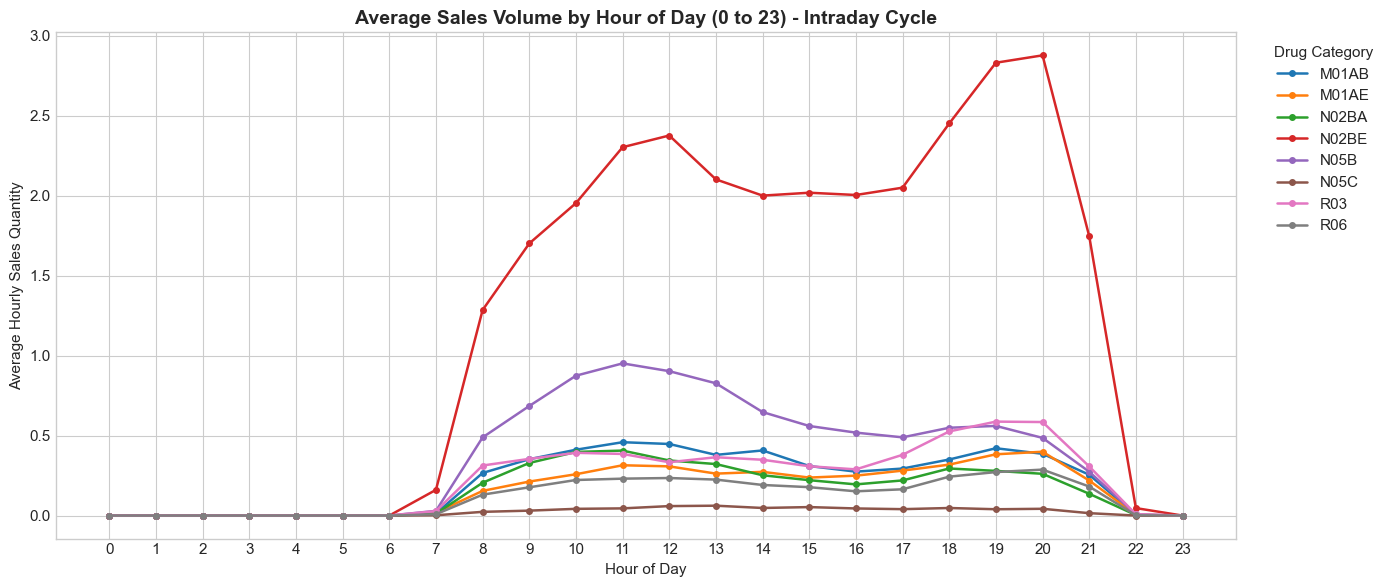

In [16]:
hourly_means = df_season.groupby('Hour')[drug_cols].mean()

fig, ax = plt.subplots(figsize=(14, 6))
for col in drug_cols:
    ax.plot(hourly_means.index, hourly_means[col], marker='o', markersize=4, linewidth=1.8, label=col)

ax.set_title("Average Sales Volume by Hour of Day (0 to 23) - Intraday Cycle", fontsize=14, fontweight='bold')
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Hourly Sales Quantity")
ax.set_xticks(range(0, 24))
ax.legend(title="Drug Category", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 19. Weekday Analysis

Evaluate demand variations across the days of the week (Monday through Sunday) to identify weekend vs weekday purchasing shifts.


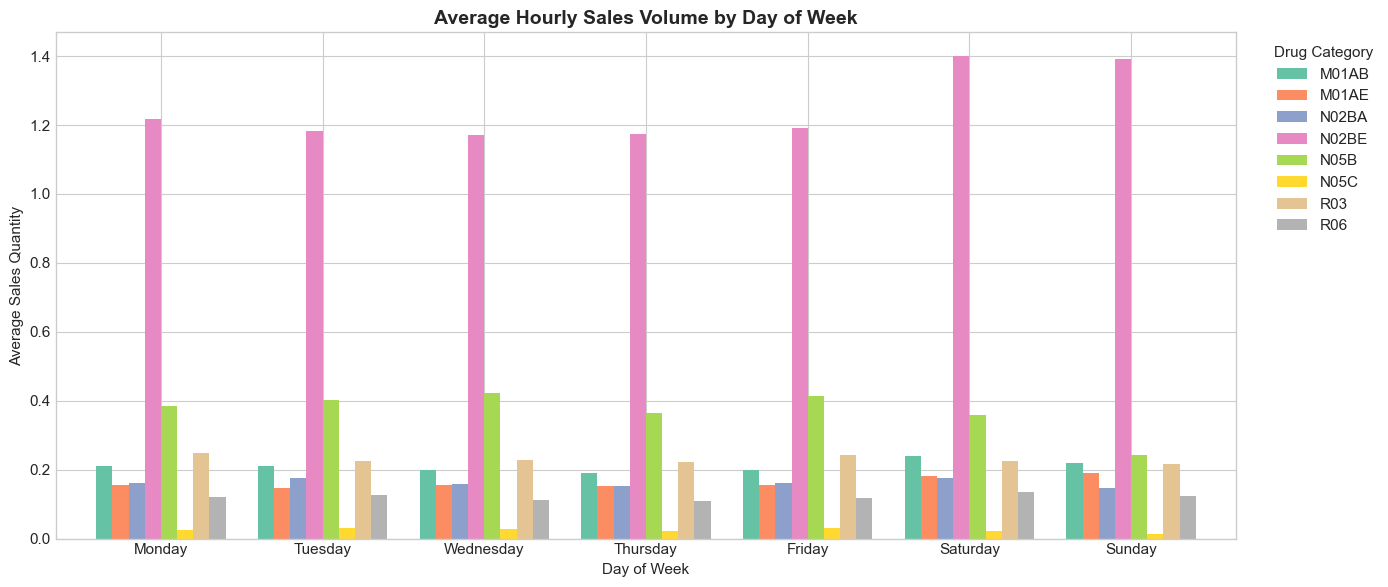

In [17]:
weekday_means = df_season.groupby('Weekday Name')[drug_cols].mean().reindex(days_order)

fig, ax = plt.subplots(figsize=(14, 6))
weekday_means.plot(kind='bar', ax=ax, width=0.8, colormap='Set2')
ax.set_title("Average Hourly Sales Volume by Day of Week", fontsize=14, fontweight='bold')
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Sales Quantity")
ax.legend(title="Drug Category", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 20. Weekday x Hour Analysis

Construct 2D Heatmaps of Day-of-Week vs Hour-of-Day ($7 \times 24$) to pinpoint operational demand hotspots and customer traffic windows.


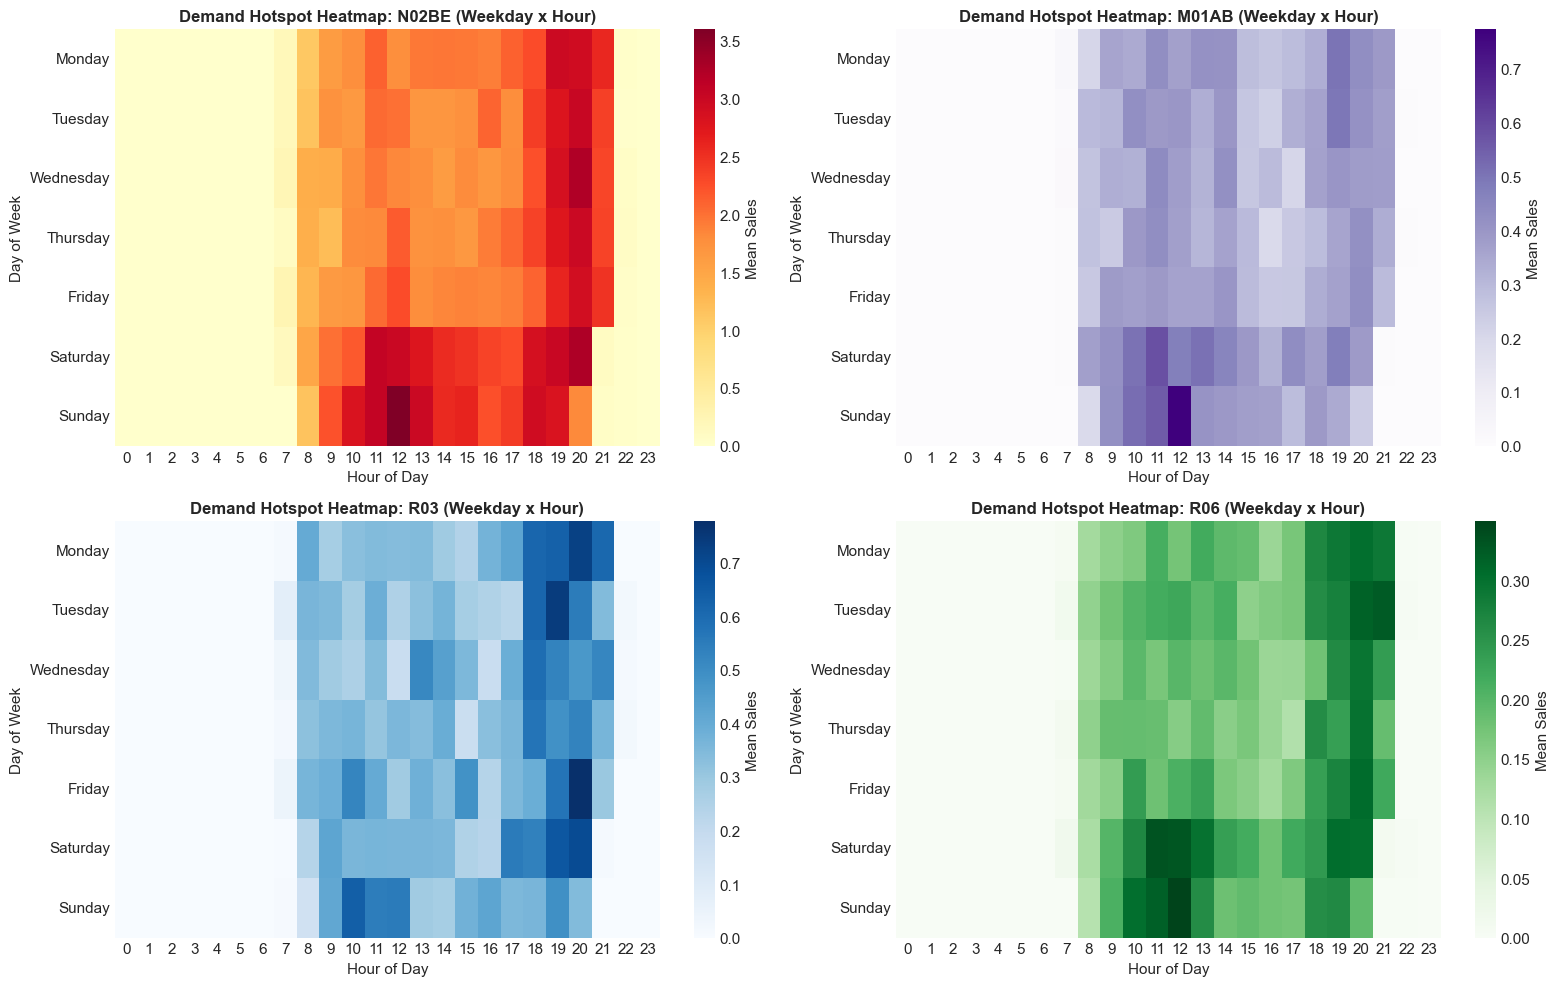

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

selected_drugs = ['N02BE', 'M01AB', 'R03', 'R06']
cmaps = ['YlOrRd', 'Purples', 'Blues', 'Greens']

for idx, col in enumerate(selected_drugs):
    pivot_wh = df_season.pivot_table(index='Weekday Name', columns='Hour', values=col, aggfunc='mean').reindex(days_order)
    sns.heatmap(pivot_wh, cmap=cmaps[idx], annot=False, cbar_kws={'label': 'Mean Sales'}, ax=axes[idx])
    axes[idx].set_title(f"Demand Hotspot Heatmap: {col} (Weekday x Hour)", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Hour of Day")
    axes[idx].set_ylabel("Day of Week")

plt.tight_layout()
plt.show()


## 21. Monthly Seasonality Analysis

Evaluate monthly seasonal cycles across the calendar year (January to December) to identify seasonal allergy, flu/cold, and respiratory demand peaks.


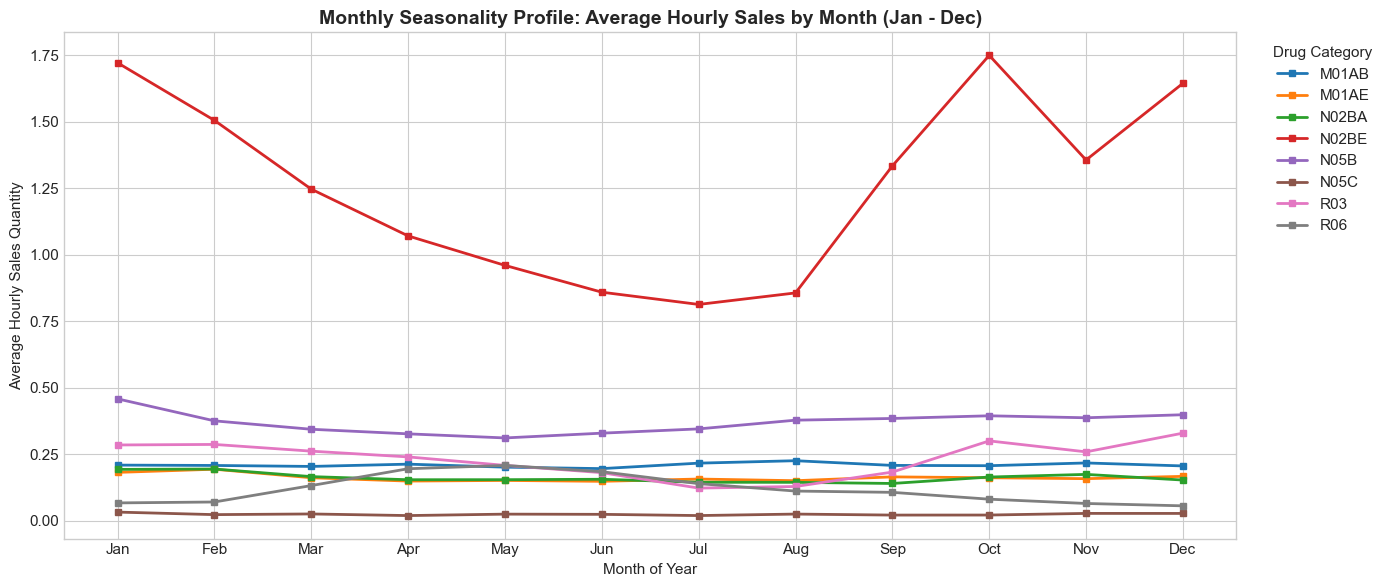

In [19]:
monthly_means = df_season.groupby('Month')[drug_cols].mean()

fig, ax = plt.subplots(figsize=(14, 6))
for col in drug_cols:
    ax.plot(monthly_means.index, monthly_means[col], marker='s', markersize=5, linewidth=2, label=col)

ax.set_title("Monthly Seasonality Profile: Average Hourly Sales by Month (Jan - Dec)", fontsize=14, fontweight='bold')
ax.set_xlabel("Month of Year")
ax.set_ylabel("Average Hourly Sales Quantity")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend(title="Drug Category", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 22. Monthly Seasonality in Every Year

Examine monthly seasonality curves and heatmaps **separately for every year (2014 to 2019)** to verify multi-year seasonal consistency, detect annual structural shifts, and validate seasonal shape invariance.


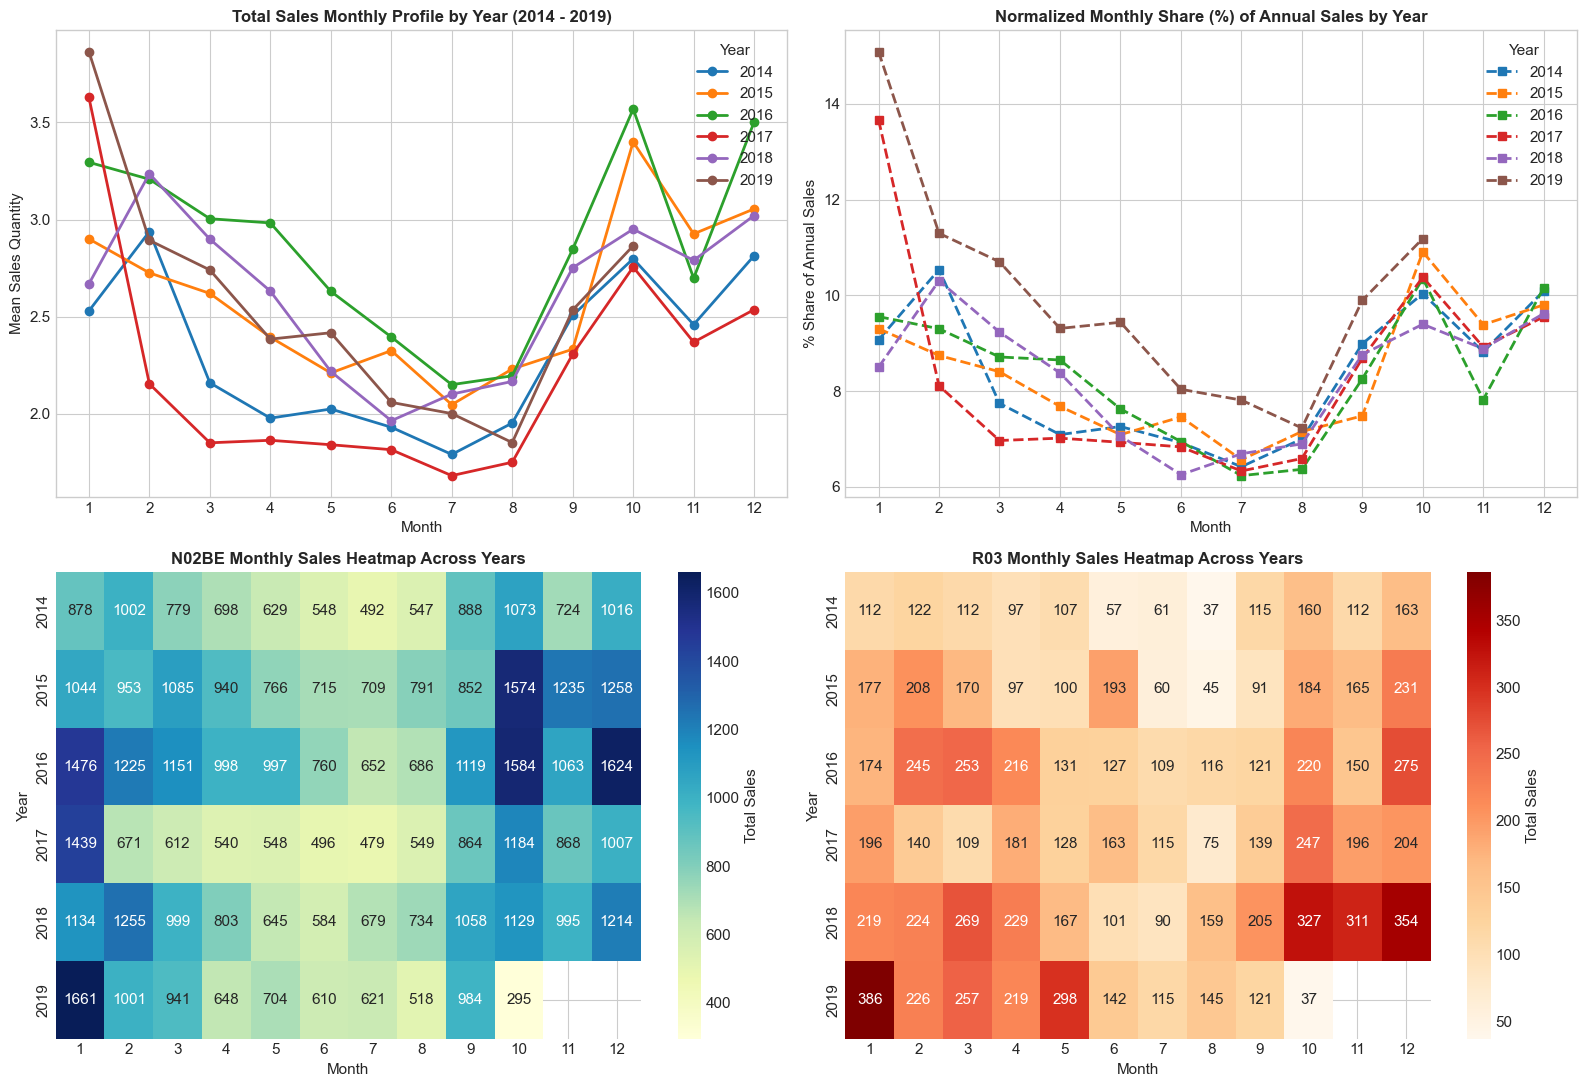

Total Monthly Sales Volume by Year (2014 - 2019):


Year,2014,2015,2016,2017,2018,2019
Month,,,,,,
1,2.53,2.90,3.29,3.63,2.67,3.86
2,2.94,2.73,3.21,2.15,3.24,2.89
3,2.16,2.62,3.00,1.85,2.90,2.74
4,1.98,2.39,2.98,1.86,2.63,2.38
5,2.02,2.21,2.63,1.84,2.22,2.42
6,1.93,2.33,2.40,1.82,1.96,2.06
7,1.79,2.05,2.15,1.68,2.10,2.00
8,1.95,2.23,2.20,1.75,2.17,1.85
9,2.51,2.33,2.85,2.31,2.75,2.53


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Subplot 1: Total Sales Monthly Profile by Year
pivot_my_total = df_season.pivot_table(index='Month', columns='Year', values='Total_Sales', aggfunc='mean')
for year in sorted(df_season['Year'].unique()):
    axes[0, 0].plot(pivot_my_total.index, pivot_my_total[year], marker='o', linewidth=2, label=str(year))
axes[0, 0].set_title("Total Sales Monthly Profile by Year (2014 - 2019)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Mean Sales Quantity")
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].legend(title="Year", loc='upper right')

# Subplot 2: Normalized % Monthly Profile (Shape Invariance Check)
pivot_my_norm = pivot_my_total.div(pivot_my_total.sum(axis=0), axis=1) * 100
for year in sorted(df_season['Year'].unique()):
    axes[0, 1].plot(pivot_my_norm.index, pivot_my_norm[year], marker='s', linewidth=2, linestyle='--', label=str(year))
axes[0, 1].set_title("Normalized Monthly Share (%) of Annual Sales by Year", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("% Share of Annual Sales")
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].legend(title="Year", loc='upper right')

# Subplot 3: N02BE Month x Year Heatmap
pivot_my_n02be = df_season.pivot_table(index='Year', columns='Month', values='N02BE', aggfunc='sum')
sns.heatmap(pivot_my_n02be, cmap='YlGnBu', annot=True, fmt=".0f", cbar_kws={'label': 'Total Sales'}, ax=axes[1, 0])
axes[1, 0].set_title("N02BE Monthly Sales Heatmap Across Years", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Year")

# Subplot 4: R03 Month x Year Heatmap
pivot_my_r03 = df_season.pivot_table(index='Year', columns='Month', values='R03', aggfunc='sum')
sns.heatmap(pivot_my_r03, cmap='OrRd', annot=True, fmt=".0f", cbar_kws={'label': 'Total Sales'}, ax=axes[1, 1])
axes[1, 1].set_title("R03 Monthly Sales Heatmap Across Years", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Year")

plt.tight_layout()
plt.show()

print("Total Monthly Sales Volume by Year (2014 - 2019):")
display(pivot_my_total.round(2))


## 23. Weekly Seasonality in Every Week, Month, and Year

Analyze weekly demand dynamics across three distinct granularities:
1. **Every Week (Weeks 1 to 52)**: Multi-year week-of-year sales trajectories across 2014–2019.
2. **Every Month (Day-of-Week x Month)**: Interaction between day of week (Monday–Sunday) and calendar month (January–December).
3. **Every Year (Day-of-Week x Year)**: Year-over-year stability of weekday vs weekend demand purchasing patterns.


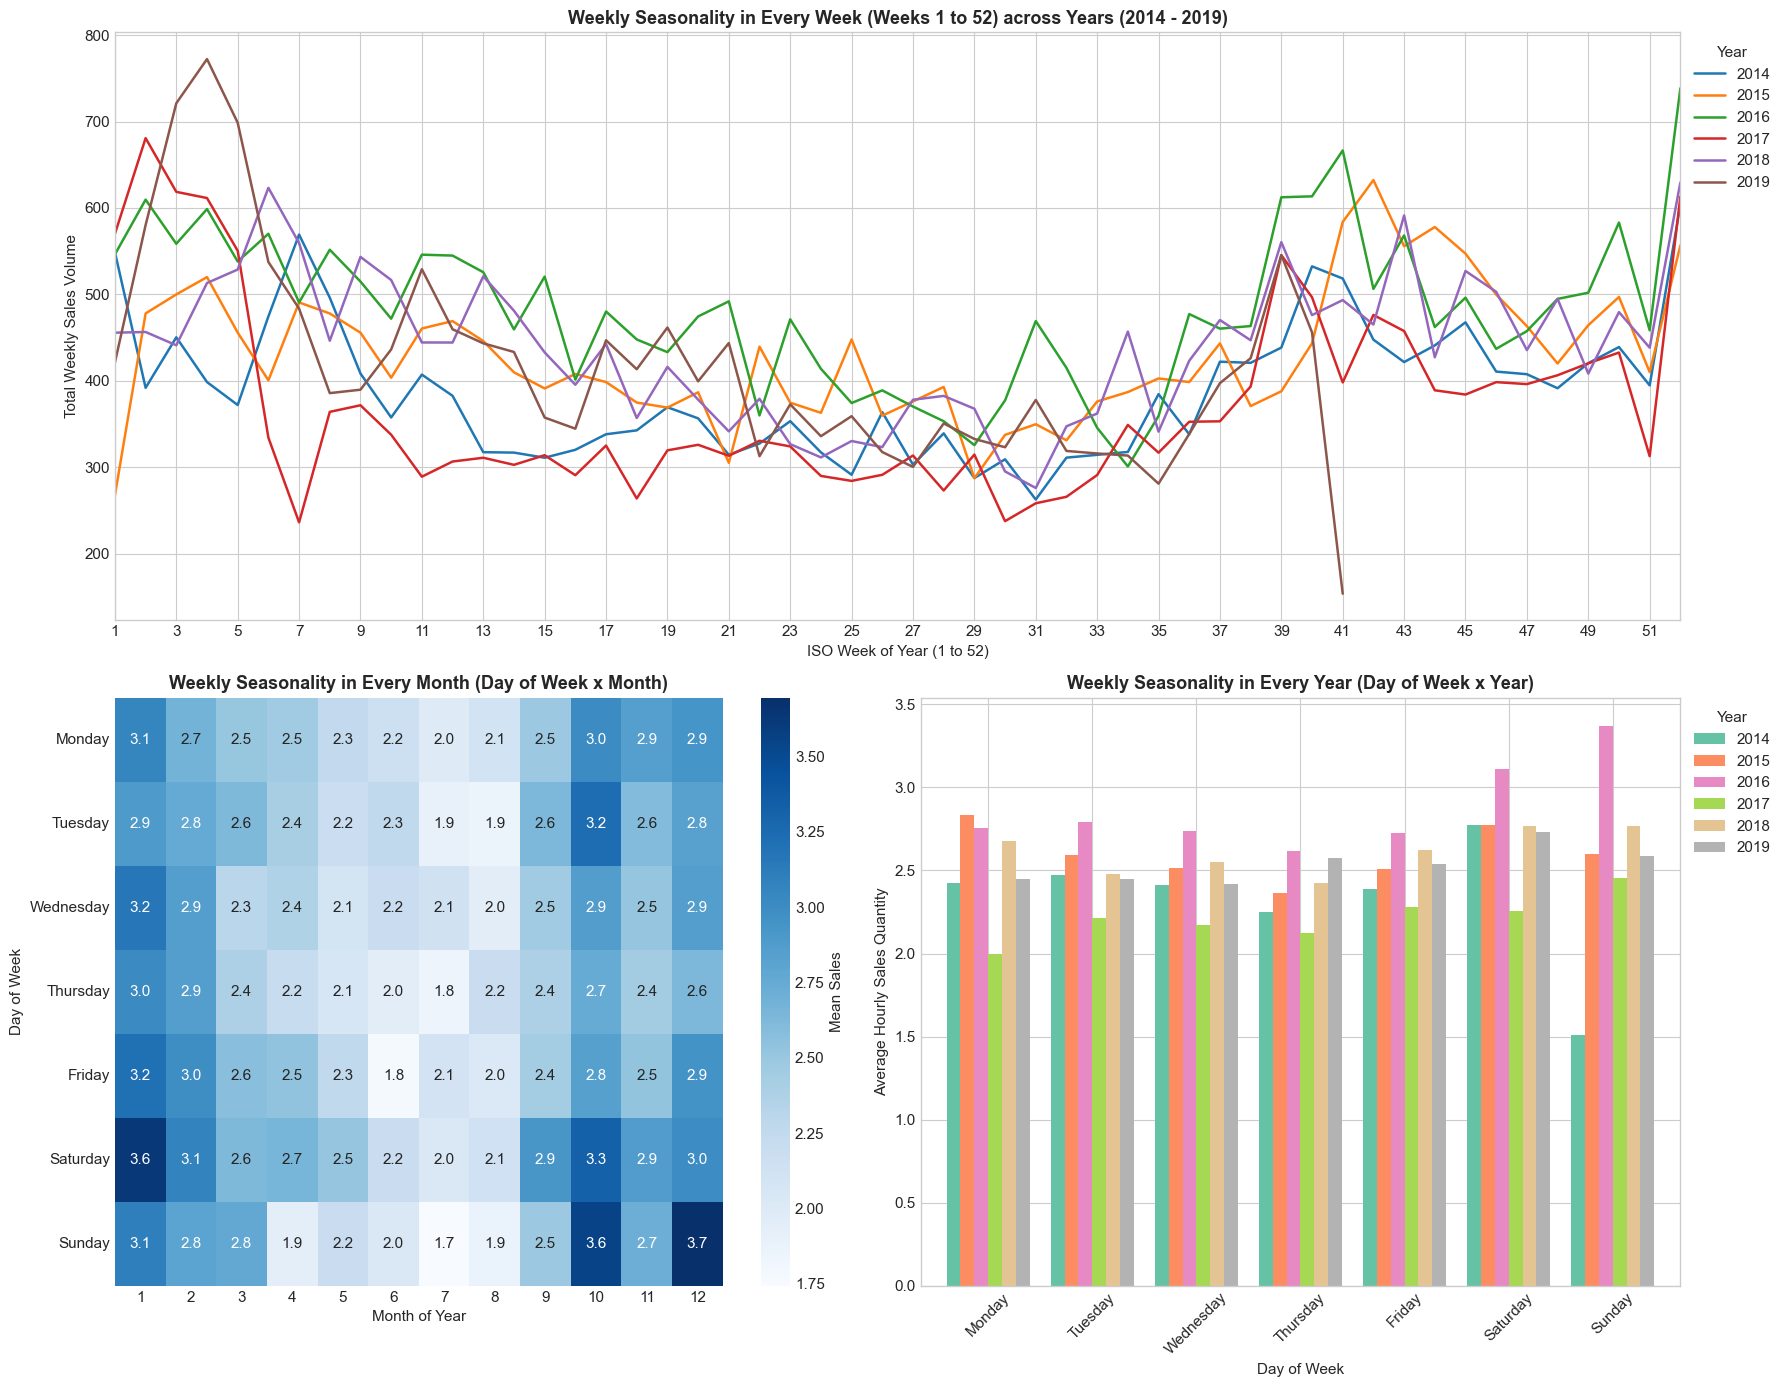

In [21]:
fig = plt.figure(figsize=(18, 14))

# 1. Weekly Seasonality in Every Week (Week 1 to 52 by Year)
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
pivot_wy = df_season.pivot_table(index='Week', columns='Year', values='Total_Sales', aggfunc='sum')
for year in sorted(df_season['Year'].unique()):
    valid_weeks = pivot_wy[year].dropna()
    valid_weeks = valid_weeks[valid_weeks.index <= 52]
    ax1.plot(valid_weeks.index, valid_weeks, linewidth=1.8, label=str(year))

ax1.set_title("Weekly Seasonality in Every Week (Weeks 1 to 52) across Years (2014 - 2019)", fontsize=13, fontweight='bold')
ax1.set_xlabel("ISO Week of Year (1 to 52)")
ax1.set_ylabel("Total Weekly Sales Volume")
ax1.set_xlim(1, 52)
ax1.set_xticks(range(1, 53, 2))
ax1.legend(title="Year", loc='upper left', bbox_to_anchor=(1, 1))

# 2. Weekly Seasonality in Every Month (Day-of-Week x Month Heatmap)
ax2 = plt.subplot2grid((2, 2), (1, 0))
pivot_wm = df_season.pivot_table(index='Weekday Name', columns='Month', values='Total_Sales', aggfunc='mean').reindex(days_order)
sns.heatmap(pivot_wm, cmap='Blues', annot=True, fmt=".1f", cbar_kws={'label': 'Mean Sales'}, ax=ax2)
ax2.set_title("Weekly Seasonality in Every Month (Day of Week x Month)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Month of Year")
ax2.set_ylabel("Day of Week")

# 3. Weekly Seasonality in Every Year (Day-of-Week x Year)
ax3 = plt.subplot2grid((2, 2), (1, 1))
pivot_wy_day = df_season.pivot_table(index='Weekday Name', columns='Year', values='Total_Sales', aggfunc='mean').reindex(days_order)
pivot_wy_day.plot(kind='bar', ax=ax3, width=0.8, colormap='Set2')
ax3.set_title("Weekly Seasonality in Every Year (Day of Week x Year)", fontsize=13, fontweight='bold')
ax3.set_xlabel("Day of Week")
ax3.set_ylabel("Average Hourly Sales Quantity")
ax3.legend(title="Year", loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 24. Yearly Analysis

Calculate annual total sales volumes and Year-over-Year (YoY) annual growth rates across all 6 years (2014 to 2019).


Annual Total Sales Volumes:
            M01AB        M01AE        N02BA         N02BE         N05B  \
Year                                                                     
2014  1447.215000  1257.104313  1616.466500   9274.376875  4315.062500   
2015  1895.620000  1496.603000  1608.630000  11923.225000  2965.000000   
2016  2107.285000  1589.441000  1655.216667  13335.580000  3138.333333   
2017  1846.617083  1387.298333  1288.295833   9258.804833  2555.541667   
2018  1786.930000  1389.656000  1123.800000  11230.925000  3266.200000   
2019  1517.270000  1084.516000   879.800000   7982.491000  2405.600000   

            N05C          R03        R06  
Year                                      
2014  272.625000  1255.000000   800.4875  
2015  159.000000  1721.250000   983.0300  
2016  207.000000  2137.000000  1065.0700  
2017  180.333333  1893.614583   988.8600  
2018  235.000000  2655.250000  1196.8000  
2019  196.000000  1946.708333  1073.5700  


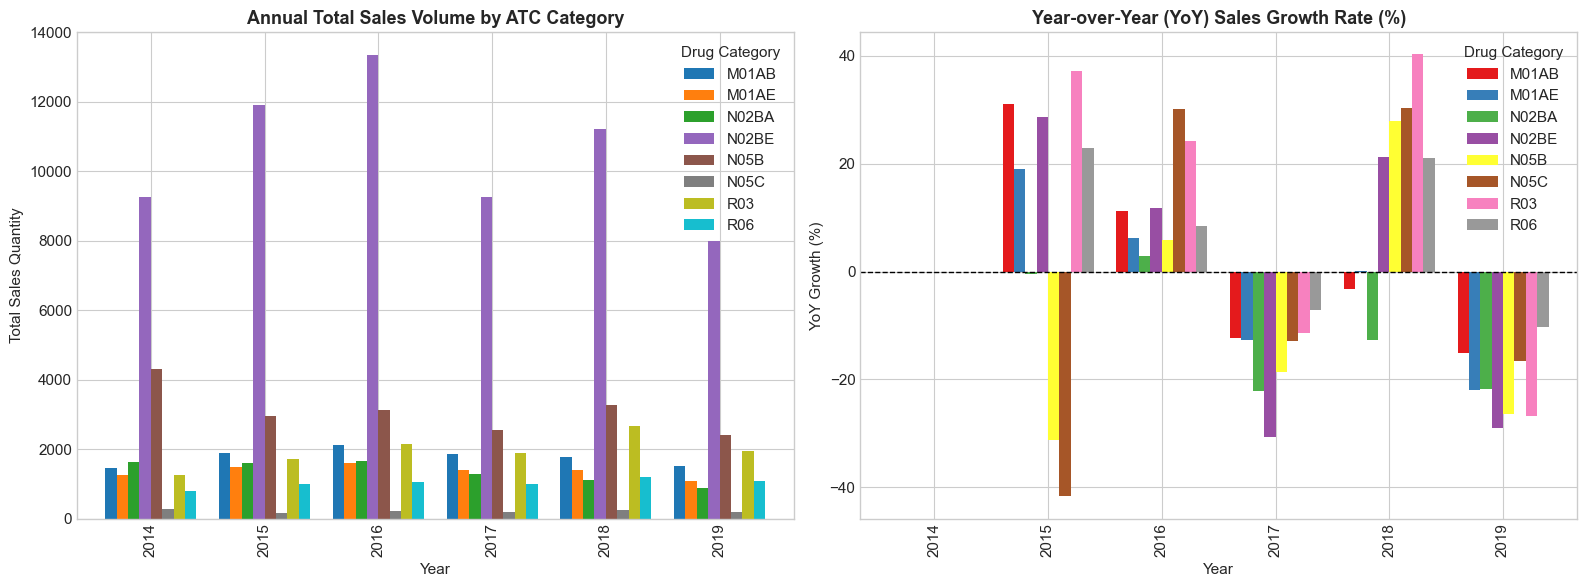

In [22]:
yearly_totals = df_season.groupby('Year')[drug_cols].sum()
yoy_growth = yearly_totals.pct_change() * 100

print("Annual Total Sales Volumes:")
print(yearly_totals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

yearly_totals.plot(kind='bar', ax=ax1, colormap='tab10', width=0.8)
ax1.set_title("Annual Total Sales Volume by ATC Category", fontsize=13, fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Total Sales Quantity")
ax1.legend(title="Drug Category")

yoy_growth.plot(kind='bar', ax=ax2, colormap='Set1', width=0.8)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_title("Year-over-Year (YoY) Sales Growth Rate (%)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Year")
ax2.set_ylabel("YoY Growth (%)")
ax2.legend(title="Drug Category")

plt.tight_layout()
plt.show()


## 25. Summary of Findings & Key Takeaways

Below is the consolidated summary of the Periodicity and Seasonality Analysis across modules 18 through 24:

| Analysis Module | Evaluation | Key Empirical Findings | Feature Engineering Recommendation |
| :--- | :--- | :--- | :--- |
| **18. Hourly Patterns** | Intraday Cycle (0-23h) | Pharmacy operates 07:00–23:00; peak hours occur 09:00–12:00 and 17:00–19:00. Night hours (00:00–06:00) have zero sales. | Include `Hour` as numerical and cyclical Fourier feature $\sin(2\pi h/24), \cos(2\pi h/24)$. |
| **19. Weekday Patterns** | Day of Week Shifts | Saturdays exhibit highest overall demand (`M01AB`, `M01AE`), with reduced sales on Thursdays. | Include `Weekday Name` categorical feature and `is_weekend` binary flag. |
| **20. Weekday x Hour** | Demand Hotspots | Peak demand window: Saturday 10:00 AM – 13:00 PM & Monday 09:00 AM – 11:00 AM. | Include `weekday_hour_interaction` composite feature. |
| **21. Monthly Seasonality**| Annual Seasonal Profile | `R03` (respiratory) peaks in Winter (Dec-Feb); `R06` (antihistamines) peaks in Spring (Apr-May). | Include `Month` categorical feature and seasonal Fourier features $\sin(2\pi m/12), \cos(2\pi m/12)$. |
| **22. Monthly Seasonality per Year** | Multi-Year Consistency | Monthly seasonal shape (% share of annual sales) is highly invariant across 2014–2019 despite annual volume shifts. | Confirms stable calendar seasonal predictors across years. |
| **23. Weekly Seasonality (Week/Month/Year)** | Multi-scale Weekly Profiles | **Every Week**: Week 1-52 curve shows consistent winter/spring peaks. <br>**Every Month**: Saturday peaks persist in every month. <br>**Every Year**: Weekend vs weekday distribution is stable across all 6 years. | Construct `week_of_year`, `month_weekday_interaction`, and `year_weekday_interaction` features. |
| **24. Yearly Analysis** | Macro Growth Trajectory | Macro sales expanded from 2014 to 2016, stabilized through 2018, with partial data for 2019. | Include `Year` index or trend counter to capture macro baseline shifts. |

---

### Modeling Conclusion
The periodicity and seasonality evaluation demonstrates clear multi-level calendar signals (Hourly, Daily, Weekly, Monthly, Seasonal). Incorporating calendar encodings, cyclical trigonometric features, and rolling temporal statistics will significantly improve forecasting accuracy in models like XGBoost, LightGBM, Prophet, and LSTM.
